MERGED DATASET - EDA 

In [1]:
import os
import re
import glob
import json
import gzip
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:

def find_project_root():
    current = os.getcwd()

    for _ in range(5):
        merged_path = os.path.join(current, "data", "merged", "merged_dataset_clean.csv")

        if os.path.exists(merged_path):
            return current

        current = os.path.dirname(current)

    raise FileNotFoundError("Could not find data/merged/merged_dataset_clean.csv")


BASE_DIR = find_project_root()

MERGED_DATA_PATH = os.path.join(BASE_DIR, "data", "merged", "merged_dataset_clean.csv")

df = pd.read_csv(MERGED_DATA_PATH, low_memory=False)

print("Merged dataset loaded from:")
print(MERGED_DATA_PATH)
print("Shape:", df.shape)

display(df.head())

Merged dataset loaded from:
/Users/marcelocorreia/Desktop/Project_2/project-nlp-business-case-automated-customers-reviews-v2/data/merged/merged_dataset_clean.csv
Shape: (129000, 7)


,review_text,rating,product_name,raw_category,source,sentiment,label
0,I've been researching hot weather underwear fo...,3.0,Unknown Product,Unknown Category,hf_amazon_reviews_multi_en,neutral,1
1,I want to love this bra! Just needs a better b...,3.0,Unknown Product,Unknown Category,hf_amazon_reviews_multi_en,neutral,1
2,Care must be taken in cooking them after stuff...,1.0,B005QJMF2Q,Grocery_and_Gourmet_Food,amazon_reviews_2023,negative,0
3,Not worth it. I bought this pack because I nee...,1.0,B004AYCNR0,Video_Games,amazon_reviews_2023,negative,0
4,Side stove spiller covers. They cover the side...,3.0,B07WTXWC32,Appliances,amazon_reviews_2023,neutral,1


In [3]:
# Create required columns for EDA

df = df.copy()

# Remove duplicate columns if they exist
df = df.loc[:, ~df.columns.duplicated()]

# Clean column names
df.columns = df.columns.str.strip()

# Make sure rating is numeric
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

# Make sure review_text is text
df["review_text"] = df["review_text"].fillna("").astype(str)

# Remove empty reviews
df = df[df["review_text"].str.strip() != ""]

def rating_to_sentiment(rating):
    if pd.isna(rating):
        return None

    rating = float(rating)

    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    elif rating >= 4:
        return "positive"
    else:
        return None

df["sentiment"] = df["rating"].apply(rating_to_sentiment)

df = df.dropna(subset=["rating", "sentiment"])

df["review_length"] = df["review_text"].apply(lambda x: len(x.split()))

print("Columns after preparation:")
print(df.columns.tolist())

print("\nShape after preparation:")
print(df.shape)

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

Columns after preparation:
['review_text', 'rating', 'product_name', 'raw_category', 'source', 'sentiment', 'label', 'review_length']

Shape after preparation:
(129000, 8)

Sentiment distribution:
sentiment
neutral     43000
negative    43000
positive    43000
Name: count, dtype: int64


In [4]:
# Output folder for Merged EDA plots

OUTPUT_DIR = os.path.join(BASE_DIR, "EDA", "eda_outputs", "merged_eda_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Merged EDA plots will be saved in:")
print(OUTPUT_DIR)

Merged EDA plots will be saved in:
/Users/marcelocorreia/Desktop/Project_2/project-nlp-business-case-automated-customers-reviews-v2/EDA/eda_outputs/merged_eda_outputs


**6. EDA**

In [5]:
# ============================================================
# EDA — Merged Dataset
# ============================================================


sns.set_theme(style="whitegrid")
fig_kw = dict(figsize=(12, 4))

# ── 1. Overview ─────────────────────────────────────────────
print("=== SHAPE ===")
print(df.shape)

print("\n=== DTYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
missing = df.isna().sum()
print(missing[missing > 0])

print("\n=== SAMPLE ===")
df.head(3)

=== SHAPE ===
(129000, 8)

=== DTYPES ===
review_text          str
rating           float64
product_name         str
raw_category         str
source               str
sentiment            str
label              int64
review_length      int64
dtype: object

=== MISSING VALUES ===
Series([], dtype: int64)

=== SAMPLE ===


,review_text,rating,product_name,raw_category,source,sentiment,label,review_length
0,I've been researching hot weather underwear fo...,3.0,Unknown Product,Unknown Category,hf_amazon_reviews_multi_en,neutral,1,99
1,I want to love this bra! Just needs a better b...,3.0,Unknown Product,Unknown Category,hf_amazon_reviews_multi_en,neutral,1,103
2,Care must be taken in cooking them after stuff...,1.0,B005QJMF2Q,Grocery_and_Gourmet_Food,amazon_reviews_2023,negative,0,21


In [6]:
# Prepare columns needed for EDA

df = df.copy()
df.columns = df.columns.str.strip()

print("Columns before preparation:")
print(df.columns.tolist())

df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["review_text"] = df["review_text"].fillna("").astype(str)

df = df[df["review_text"].str.strip() != ""]
df = df.dropna(subset=["rating"])

def rating_to_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    elif rating >= 4:
        return "positive"
    else:
        return None

df["sentiment"] = df["rating"].apply(rating_to_sentiment)
df = df.dropna(subset=["sentiment"])

df["review_length"] = df["review_text"].apply(lambda x: len(str(x).split()))

print("\nColumns after preparation:")
print(df.columns.tolist())

print("\nShape:")
print(df.shape)

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

Columns before preparation:
['review_text', 'rating', 'product_name', 'raw_category', 'source', 'sentiment', 'label', 'review_length']

Columns after preparation:
['review_text', 'rating', 'product_name', 'raw_category', 'source', 'sentiment', 'label', 'review_length']

Shape:
(129000, 8)

Sentiment distribution:
sentiment
neutral     43000
negative    43000
positive    43000
Name: count, dtype: int64


=== SENTIMENT DISTRIBUTION ===
           count  percent (%)
sentiment                    
neutral    43000        33.33
negative   43000        33.33
positive   43000        33.33


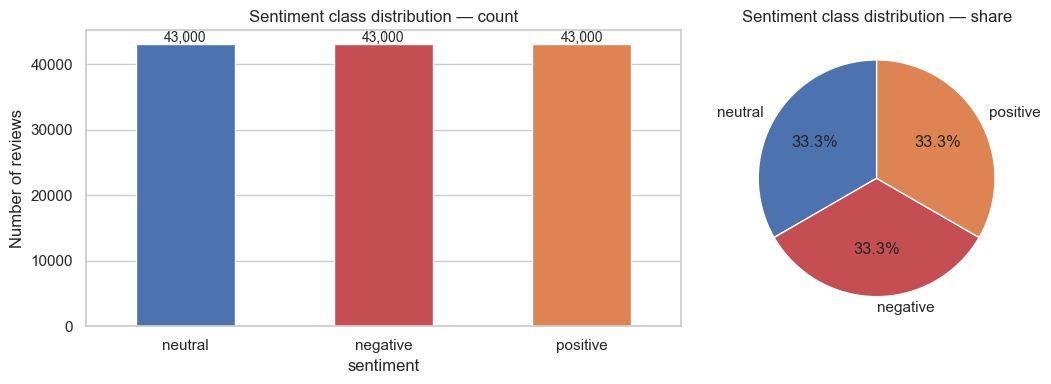

In [7]:
# ── 2. Class distribution ───────────────────────────────────
print("=== SENTIMENT DISTRIBUTION ===")
dist = df["sentiment"].value_counts()
pct  = df["sentiment"].value_counts(normalize=True) * 100
print(pd.DataFrame({"count": dist, "percent (%)": pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count
dist.plot(kind="bar", ax=axes[0],
          color=["#4C72B0", "#C44E52", "#DD8452"])
axes[0].set_title("Sentiment class distribution — count")
axes[0].set_ylabel("Number of reviews")
axes[0].set_xticklabels(dist.index, rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}",
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=10)

# Percentage pie
axes[1].pie(dist, labels=dist.index, autopct="%1.1f%%",
            colors=["#4C72B0", "#C44E52", "#DD8452"],
            startangle=90)
axes[1].set_title("Sentiment class distribution — share")

plt.tight_layout()


plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sentiment_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

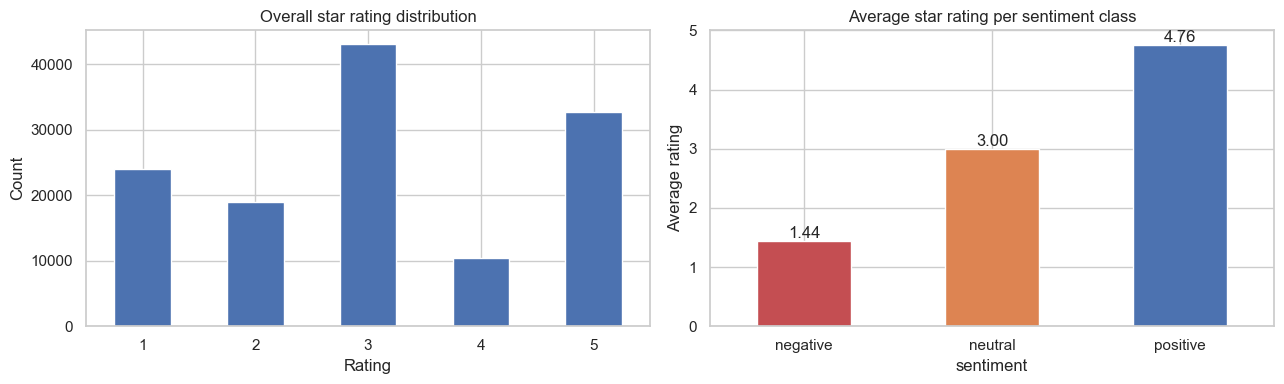

In [8]:
# ── 3. Rating distribution (overall & per sentiment) ────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df["rating"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Overall star rating distribution")
axes[0].set_xlabel("Rating"); axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["1", "2", "3", "4", "5"], rotation=0)

# Average rating per sentiment class
df.groupby("sentiment")["rating"].mean().reindex(
    ["negative", "neutral", "positive"]).plot(
    kind="bar", ax=axes[1],
    color=["#C44E52", "#DD8452", "#4C72B0"])
axes[1].set_title("Average star rating per sentiment class")
axes[1].set_ylabel("Average rating")
axes[1].set_xticklabels(["negative", "neutral", "positive"], rotation=0)
axes[1].set_ylim(0, 5)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}",
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom")

plt.tight_layout()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "rating_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

=== SOURCE BREAKDOWN ===
source
primary                       45790
hf_amazon_reviews_multi_en    42463
amazon_reviews_2023           40747
Name: count, dtype: int64



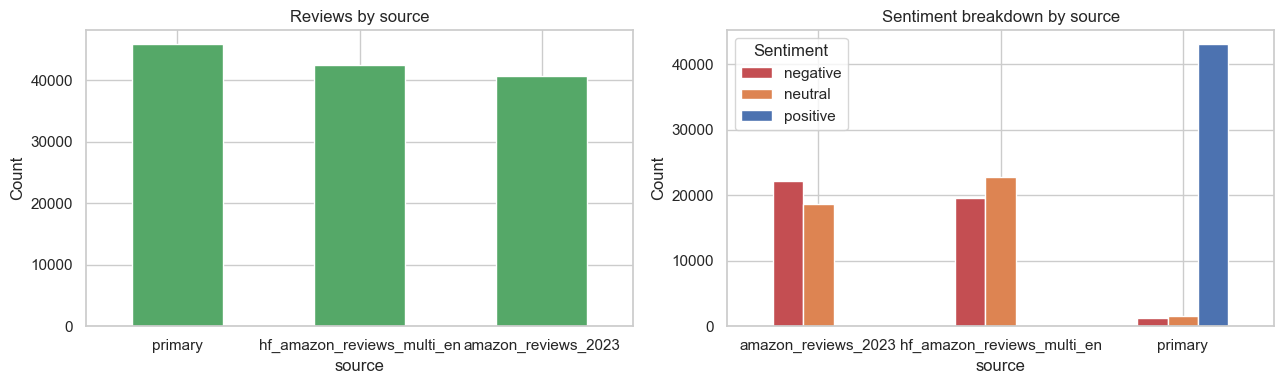

In [9]:
# ── 4. Source breakdown ─────────────────────────────────────
print("=== SOURCE BREAKDOWN ===")
print(df["source"].value_counts())
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df["source"].value_counts().plot(kind="bar", ax=axes[0], color="#55A868")
axes[0].set_title("Reviews by source")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(df["source"].value_counts().index, rotation=0)

# Sentiment split per source
df.groupby(["source", "sentiment"]).size().unstack(fill_value=0).plot(
    kind="bar", ax=axes[1],
    color=["#C44E52", "#DD8452", "#4C72B0"])
axes[1].set_title("Sentiment breakdown by source")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title="Sentiment")

plt.tight_layout()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "source_breakdown.png"), dpi=300, bbox_inches="tight")
plt.show()

=== REVIEW LENGTH (words) ===
             count  mean   std  min   25%   50%   75%     max
sentiment                                                    
negative   43000.0  50.3  70.2  1.0  15.0  30.0  58.0  2043.0
neutral    43000.0  60.1  91.2  1.0  16.0  33.0  68.0  3363.0
positive   43000.0  28.1  33.8  1.0  12.0  19.0  33.0  1864.0


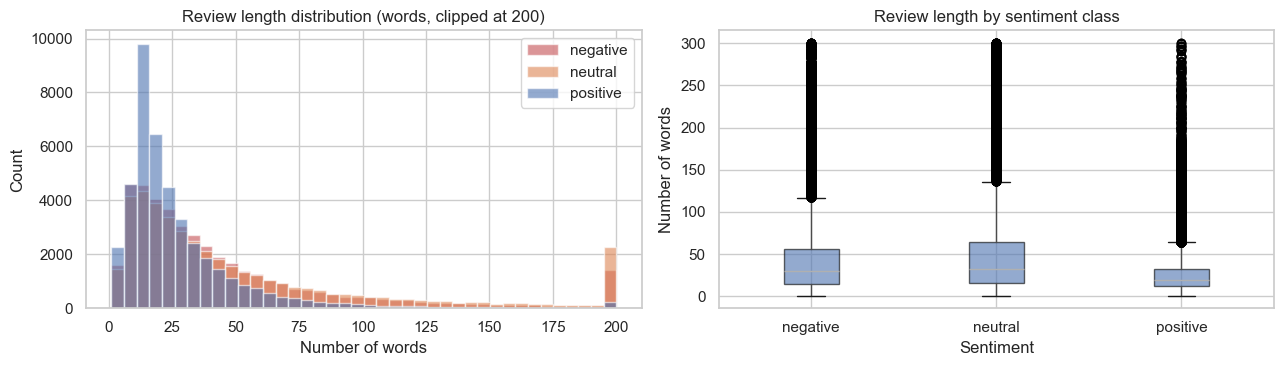

In [10]:
# ── 5. Review length distribution ──────────────────────────
df["review_length"] = df["review_text"].astype(str).str.split().str.len()

print("=== REVIEW LENGTH (words) ===")
print(df.groupby("sentiment")["review_length"].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
for label, color in zip(["negative", "neutral", "positive"],
                         ["#C44E52", "#DD8452", "#4C72B0"]):
    sub = df[df["sentiment"] == label]["review_length"]
    axes[0].hist(sub.clip(upper=200), bins=40, alpha=0.6,
                 label=label, color=color)
axes[0].set_title("Review length distribution (words, clipped at 200)")
axes[0].set_xlabel("Number of words")
axes[0].set_ylabel("Count")
axes[0].legend()

# Boxplot
df[df["review_length"] <= 300].boxplot(
    column="review_length", by="sentiment",
    ax=axes[1], patch_artist=True,
    boxprops=dict(facecolor="#4C72B0", alpha=0.6))
axes[1].set_title("Review length by sentiment class")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Number of words")
plt.suptitle("")   # remove auto-title from boxplot

plt.tight_layout()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "review_length_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

=== TOP 15 PRODUCTS BY REVIEW COUNT ===
product_name
Unknown Product                                                                                                                                         48663
Fire Tablet, 7 Display, Wi - Fi, 8 GB - Includes Special Offers, Magenta                                                                                10551
AmazonBasics AAA Performance Alkaline Batteries (36 Count)                                                                                               6238
Echo (White), Echo (White)                                                                                                                               3240
Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Paperwhite - touchscreen - Wi - Fi - black                                                 2949
Amazon Fire Tv, Amazon Fire Tv                                                                                                                           2484

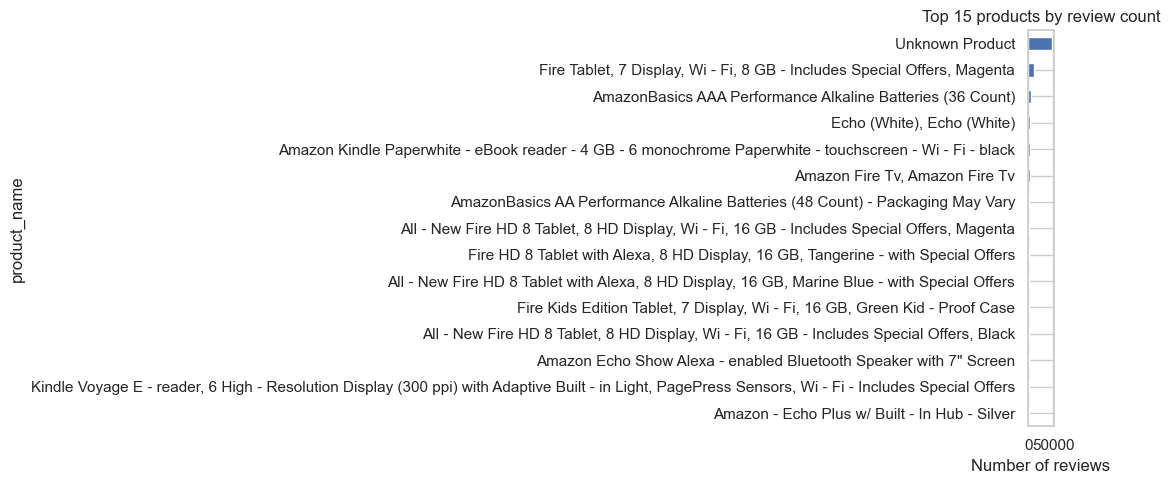

In [11]:
# ── 6. Top products ─────────────────────────────────────────
print("=== TOP 15 PRODUCTS BY REVIEW COUNT ===")
top_products = df["product_name"].value_counts().head(15)
print(top_products)

top_products.plot(kind="barh", figsize=(11, 5), color="#4C72B0")
plt.gca().invert_yaxis()
plt.title("Top 15 products by review count")
plt.xlabel("Number of reviews")
plt.tight_layout()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top_products.png"), dpi=300, bbox_inches="tight")
plt.show()

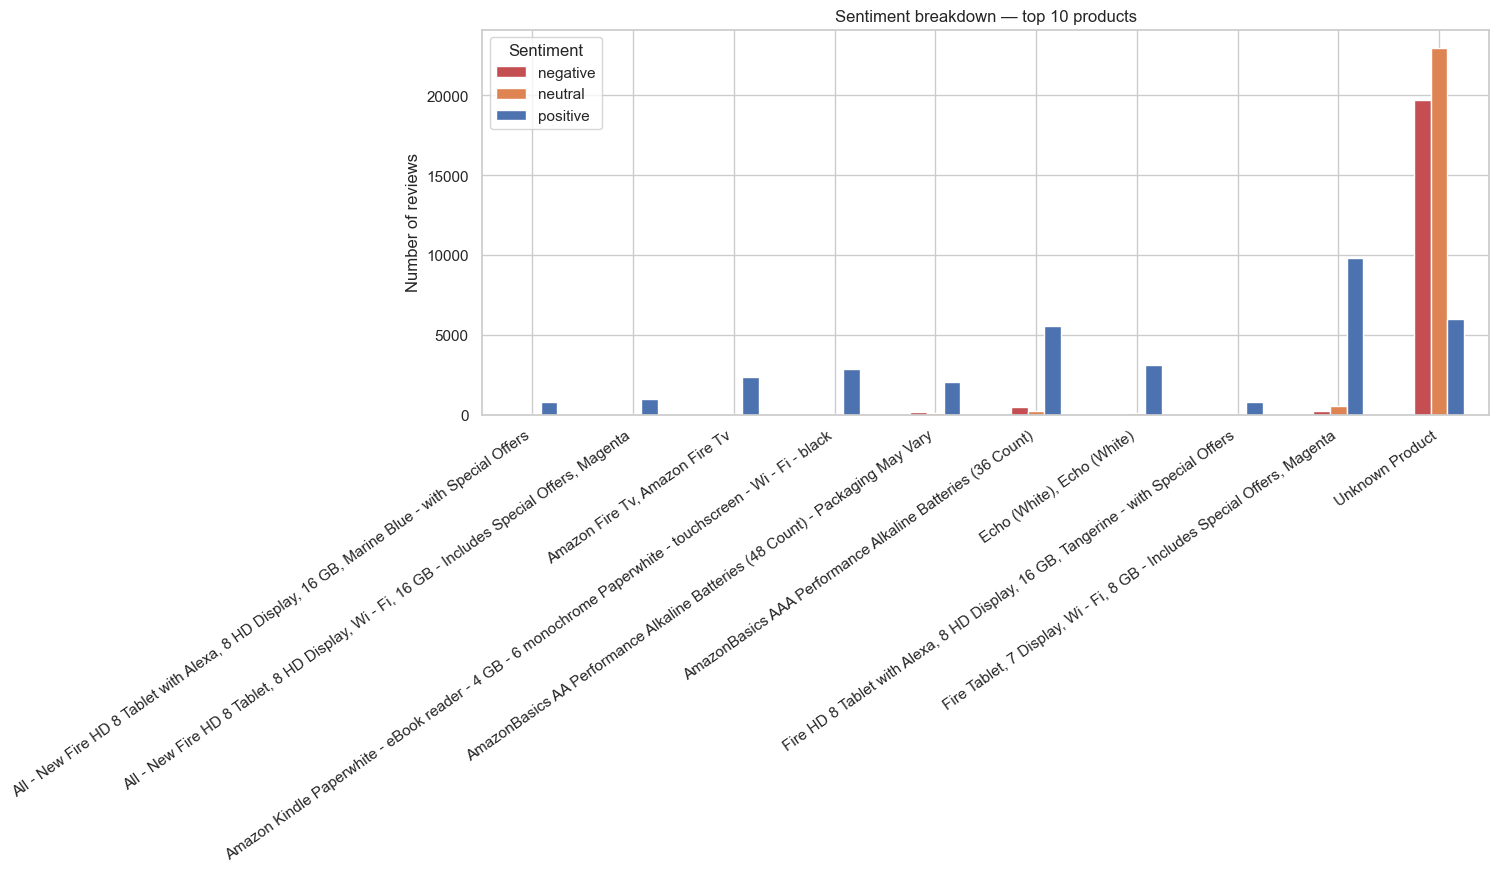

In [12]:
# ── 7. Sentiment per top product ────────────────────────────
top10_names = df["product_name"].value_counts().head(10).index

pivot = (df[df["product_name"].isin(top10_names)]
         .groupby(["product_name", "sentiment"])
         .size()
         .unstack(fill_value=0))

pivot.plot(kind="bar", figsize=(13, 5),
           color=["#C44E52", "#DD8452", "#4C72B0"])
plt.title("Sentiment breakdown — top 10 products")
plt.ylabel("Number of reviews")
plt.xlabel("")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Sentiment")
plt.tight_layout()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sentiment_per_top_product.png"), dpi=300, bbox_inches="tight")
plt.show()

=== TOP 15 RAW CATEGORIES ===
raw_category
Unknown Category               42463
Fire Tablets                   15730
AA                              8555
Stereos                         6504
Back To College                 4980
Walmart for Business            3476
Electronics                     2701
Subscription_Boxes              2448
Software                        2005
Amazon_Fashion                  1712
All_Beauty                      1694
Health_and_Personal_Care        1602
Magazine_Subscriptions          1535
Cell_Phones_and_Accessories     1503
Beauty_and_Personal_Care        1492
Name: count, dtype: int64


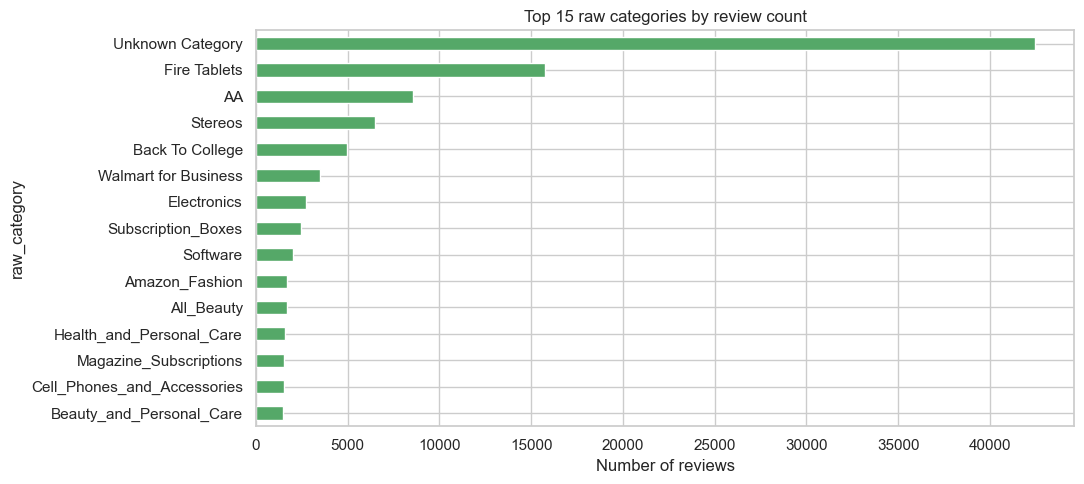

In [13]:
# ── 8. Raw category distribution ───────────────────────────
print("=== TOP 15 RAW CATEGORIES ===")
top_cats = df["raw_category"].value_counts().head(15)
print(top_cats)

top_cats.plot(kind="barh", figsize=(11, 5), color="#55A868")
plt.gca().invert_yaxis()
plt.title("Top 15 raw categories by review count")
plt.xlabel("Number of reviews")
plt.tight_layout()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "raw_category_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

In [14]:
# --- 9. EDA summary ------------------------------------------------

dist = df["sentiment"].value_counts()
pct = df["sentiment"].value_counts(normalize=True) * 100

print("=" * 50)
print("EDA SUMMARY")
print("=" * 50)
print(f"Total reviews       : {len(df):,}")
print(f"Unique products     : {df['product_name'].nunique():,}")
print(f"Unique categories   : {df['raw_category'].nunique():,}")
print(f"Sources             : {df['source'].unique().tolist()}")
print(f"Avg review length   : {df['review_length'].mean():.1f} words")
print(f"Median length       : {df['review_length'].median():.0f} words")
print()
print("Class balance:")
print(pd.DataFrame({"count": dist, "percent (%)": pct.round(2)}))

summary_df = pd.DataFrame({
    "metric": [
        "total_reviews",
        "unique_products",
        "unique_categories",
        "sources",
        "avg_review_length_words",
        "median_review_length_words",
        "positive_reviews",
        "negative_reviews",
        "neutral_reviews",
        "positive_percent",
        "negative_percent",
        "neutral_percent"
    ],
    "value": [
        len(df),
        df["product_name"].nunique(),
        df["raw_category"].nunique(),
        ", ".join(df["source"].unique().tolist()),
        round(df["review_length"].mean(), 1),
        round(df["review_length"].median(), 0),
        int(dist.get("positive", 0)),
        int(dist.get("negative", 0)),
        int(dist.get("neutral", 0)),
        round(pct.get("positive", 0), 2),
        round(pct.get("negative", 0), 2),
        round(pct.get("neutral", 0), 2)
    ]
})

summary_path = os.path.join(OUTPUT_DIR, "merged_eda_summary.csv")
summary_df.to_csv(summary_path, index=False)

print()
print("Summary saved in:")
print(summary_path)

display(summary_df)

EDA SUMMARY
Total reviews       : 129,000
Unique products     : 35,073
Unique categories   : 74
Sources             : ['hf_amazon_reviews_multi_en', 'amazon_reviews_2023', 'primary']
Avg review length   : 46.2 words
Median length       : 26 words

Class balance:
           count  percent (%)
sentiment                    
neutral    43000        33.33
negative   43000        33.33
positive   43000        33.33

Summary saved in:
/Users/marcelocorreia/Desktop/Project_2/project-nlp-business-case-automated-customers-reviews-v2/EDA/eda_outputs/merged_eda_outputs/merged_eda_summary.csv


,metric,value
0,total_reviews,129000
1,unique_products,35073
2,unique_categories,74
3,sources,"hf_amazon_reviews_multi_en, amazon_reviews_202..."
4,avg_review_length_words,46.2
5,median_review_length_words,26.0
6,positive_reviews,43000
7,negative_reviews,43000
8,neutral_reviews,43000
9,positive_percent,33.33
